# LLR Comparison: Base ESM2 vs Single-Domain LoRA-Finetuned — per (NUM_SAMPLES, RANDOM_SEED) run

Loads the per-run LLR comparison dictionaries written by
`ESM_domainome_llr_ns_rs_sd_compare_dictall_2.ipynb` to GCS at
`gs://{bucket}/{prefix}/{run_id}/llr_comparison_all.pkl.gz`
(one per single-domain `(FT_DOMAIN_ID, NUM_SAMPLES, RANDOM_SEED)` combination,
e.g. `single_domain_P19878_PF00018_241_ns40_seed37`) and computes Spearman
correlation between the base / finetuned LLR matrices and the measured fitness
values per `(run_id, domain_id)`.

Each loaded payload tags every domain entry with `in_train=True` for the single
domain that was actually used to finetune that run, so downstream analyses can
separate in-train vs held-out generalisation.

All GCS payloads (per-run pickles, the fitness dict, and the seed-38 sweep
JSONs) are streamed directly into memory — nothing downloaded from GCS is
persisted to local disk.


In [1]:
import os
import io
from io import BytesIO
import gzip
import json
import pickle
import warnings
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm
from dotenv import load_dotenv
from transformers import EsmForMaskedLM, EsmTokenizer
from peft import LoraConfig, get_peft_model
from google.cloud import storage

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)

/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.4.6)
  from scipy.stats import gaussian_kde
/opt/anaconda3/envs/MachLearn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ── Constants (must match training / dictall run) ────────────────────────────

AA_ORDER         = ['L', 'A', 'G', 'V', 'S', 'E', 'R', 'T', 'I', 'D',
                    'P', 'K', 'Q', 'N', 'F', 'Y', 'M', 'H', 'W', 'C']
FITNESS_AA_ORDER = list("ACDEFGHIKLMNPQRSTVWY")
MODEL_NAME       = "facebook/esm2_t33_650M_UR50D"
MAX_LEN          = 1022
LORA_DROPOUT     = 0.1

# ── GCS layout (must match single-domain dictall run) ────────────────────────
#
# This notebook is fully in-memory: nothing downloaded from GCS is persisted
# to local disk. All payloads are streamed into BytesIO and unpickled directly.

GCS_PROJECT           = "plm-study-484223"
GCS_BUCKET            = "domainome-data"
GCS_DOMAIN_DATA_BLOB  = "ESM2/dict_fitness.pkl.gz"
GCS_FULL_PROTEIN_BLOB = "ESM2/dict_domainome_uniprot_new.pkl.gz"
GCS_OUTPUT_PREFIX     = "ESM2/ft_single_domain_NS_RS/"   # must end with /; matches ESM_domainome_llr_ns_rs_sd_compare_dictall_2.ipynb

# Where the per-run LLR comparison pickles live in GCS (one per run_id, e.g.
# `single_domain_P19878_PF00018_241_ns40_seed37`).
LLR_OUTPUT_NAME = "llr_comparison_all.pkl.gz"


def pfam_paths(run_id):
    """Resolve the GCS blob path for a single per-(FT_DOMAIN_ID, NUM_SAMPLES, RANDOM_SEED) run."""
    return {
        "run_id":  run_id,
        "gcs_llr": f"{GCS_OUTPUT_PREFIX}{run_id}/{LLR_OUTPUT_NAME}",
    }


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [3]:
# ── GCS Helpers (all in-memory; nothing is written to local disk) ────────────
load_dotenv()
cred_path = os.getenv('GOOGLE_APPLICATION_CREDENTIALS')

os.environ['GOOGLE_APPLICATION_CREDENTIALS'] = cred_path

# _gcs_client = storage.Client(project=GCS_PROJECT) if GCS_PROJECT else storage.Client()
_gcs_client = storage.Client()
_gcs_bucket = _gcs_client.bucket(GCS_BUCKET)


def gcs_download_pickle_gz(blob):
    """Stream a gzipped pickle blob into memory and unpickle in place."""
    data = blob.download_as_bytes()
    with gzip.GzipFile(fileobj=io.BytesIO(data), mode="rb") as gz:
        return pickle.load(gz)


def gcs_load_pickle_gz_by_path(blob_path):
    """Convenience: like gcs_download_pickle_gz but takes a blob path string."""
    return gcs_download_pickle_gz(_gcs_bucket.blob(blob_path))


def gcs_upload_bytes(blob_path, data_bytes, content_type="application/octet-stream"):
    """Upload raw bytes from memory to a GCS blob (no local file required)."""
    blob = _gcs_bucket.blob(blob_path)
    blob.upload_from_file(
        io.BytesIO(data_bytes),
        size=len(data_bytes),
        content_type=content_type,
    )

In [4]:
# ── Helpers (mirrored from training notebook) ────────────────────────────────

def truncate_to_domain(sequence, domain_start, domain_end, max_len=MAX_LEN):
    seq_len    = len(sequence)
    domain_mid = (domain_start + domain_end) // 2
    half       = max_len // 2
    start      = max(0, domain_mid - 1 - half)
    end        = start + max_len
    if end > seq_len:
        end   = seq_len
        start = max(0, end - max_len)
    return sequence[start:end], start


def get_LLR_scores(sequence, model, tokenizer, device):
    seq_list  = list(sequence)
    tokenized = tokenizer(sequence, padding=False, truncation=True,
                          max_length=1024, return_tensors="pt")
    input_ids = tokenized["input_ids"].to(device)

    logits    = model(input_ids).logits
    log_probs = torch.log_softmax(logits, dim=-1)
    wt_logits = log_probs[:, 1:-1, :].squeeze(0)

    wt_logits_df = pd.DataFrame(
        wt_logits[:, 4:24].cpu().detach().numpy(),
        columns=AA_ORDER,
        index=[f"{aa} {i+1}" for i, aa in enumerate(seq_list)]
    ).T

    wt_norm = np.diag(wt_logits_df.loc[[c.split(" ")[0] for c in wt_logits_df.columns]])
    LLR     = wt_logits_df - wt_norm
    return LLR, wt_logits, seq_list


def fitness_matrix_to_rows(fitness, dom_seq, position_offset=0):
    rows = []
    for i, wt_aa in enumerate(dom_seq):
        if i >= len(fitness):
            break
        row = fitness[i]
        for j, mut_aa in enumerate(FITNESS_AA_ORDER):
            if j >= len(row):
                continue
            val = row[j]
            if val is None:
                continue
            try:
                fval = float(val)
            except (TypeError, ValueError):
                continue
            if np.isnan(fval):
                continue
            if mut_aa == wt_aa:
                continue
            rows.append({
                "position":           position_offset + i + 1,
                "wt_aa":              wt_aa,
                "mut_aa":             mut_aa,
                "normalized_fitness": fval,
            })
    return rows


def build_lora_model(lora_r, lora_alpha):
    """Rebuild the exact ESM2 + LoRA architecture used during training."""
    model       = EsmForMaskedLM.from_pretrained(MODEL_NAME)
    lora_config = LoraConfig(
        task_type      = "FEATURE_EXTRACTION",
        r              = lora_r,
        lora_alpha     = lora_alpha,
        target_modules = ["query", "key", "value", "output.dense"],
        lora_dropout   = LORA_DROPOUT,
    )
    model = get_peft_model(model, lora_config)
    return model

In [5]:
# ── Discover run_ids and load per-run LLR comparison dicts (in-memory) ──────
#
# `ESM_domainome_llr_ns_rs_sd_compare_dictall_2.ipynb` writes one
# `llr_comparison_all.pkl.gz` per single-domain run under
# `gs://{bucket}/{prefix}/{run_id}/`, where `{run_id}` is e.g.
# `single_domain_P19878_PF00018_241_ns40_seed37`. We list every such blob and
# stream each pickle straight from GCS into memory — nothing is written to
# local disk. After this cell, `run_payloads[run_id] = payload` for every run
# whose pickle could be loaded.

RUN_IDS = sorted({
    blob.name[len(GCS_OUTPUT_PREFIX):].split("/", 1)[0]
    for blob in _gcs_client.list_blobs(GCS_BUCKET, prefix=GCS_OUTPUT_PREFIX)
    if blob.name.endswith(f"/{LLR_OUTPUT_NAME}")
    and blob.name[len(GCS_OUTPUT_PREFIX):].count("/") == 1
})

print(f"Found {len(RUN_IDS)} runs with {LLR_OUTPUT_NAME} "
      f"under gs://{GCS_BUCKET}/{GCS_OUTPUT_PREFIX}")
print(RUN_IDS[:10], "..." if len(RUN_IDS) > 10 else "")

run_payloads = {}

for run_id in tqdm(RUN_IDS, desc="Loading per-run payloads"):
    paths = pfam_paths(run_id)
    try:
        run_payloads[run_id] = gcs_load_pickle_gz_by_path(paths["gcs_llr"])
    except Exception as exc:
        print(f"[{run_id}] load failed: {exc}")
        continue

print(f"Loaded payloads for {len(run_payloads)} runs (all in memory)")
if run_payloads:
    sample_run     = next(iter(run_payloads))
    sample_payload = run_payloads[sample_run]
    sample_id      = next(iter(sample_payload["domains"]))
    sample         = sample_payload["domains"][sample_id]
    print(f"Sample run={sample_run} domain={sample_id} "
          f"seq_len={len(sample['sequence'])} "
          f"base_llr={sample['base_llr'].shape} "
          f"ft_llr={sample['ft_llr'].shape}")

Found 25 runs with llr_comparison_all.pkl.gz under gs://domainome-data/ESM2/ft_single_domain_NS_RS/
['single_domain_P14653_PF00046_208_ns10_seed37', 'single_domain_P14653_PF00046_208_ns10_seed38', 'single_domain_P14653_PF00046_208_ns10_seed39', 'single_domain_P14653_PF00046_208_ns10_seed40', 'single_domain_P14653_PF00046_208_ns10_seed41', 'single_domain_P14653_PF00046_208_ns20_seed37', 'single_domain_P14653_PF00046_208_ns20_seed38', 'single_domain_P14653_PF00046_208_ns20_seed39', 'single_domain_P14653_PF00046_208_ns20_seed40', 'single_domain_P14653_PF00046_208_ns20_seed41'] ...


Loading per-run payloads: 100%|██████████| 25/25 [08:00<00:00, 19.21s/it]

Loaded payloads for 25 runs (all in memory)
Sample run=single_domain_P14653_PF00046_208_ns10_seed37 domain=A0A2R8Y422_PF00240_2 seq_len=70 base_llr=(20, 70) ft_llr=(20, 70)


In [6]:
# ── Spearman: fitness vs (base LLR, finetuned LLR) per domain × run ─────────
#
# For every (run_id, domain) pair in `run_payloads`, line up each measured
# (position, mut_aa) fitness value with the corresponding entry in the base and
# finetuned LLR matrices and compute Spearman ρ separately for base and ft.
# `num_samples`, `random_seed`, the trained `ft_domain_id` parsed from the
# run_id, and the per-entry `in_train` flag (True for the single domain the
# LoRA was finetuned on) are also recorded so downstream plots can stratify by
# run config and split in-train vs held-out domains.

import re
from scipy.stats import spearmanr

# run_id format from ESM_domainome_llr_ns_rs_sd_compare_dictall_2.ipynb:
#   single_domain_{ft_domain_id}_ns{NUM_SAMPLES}_seed{RANDOM_SEED}
# where {ft_domain_id} itself contains underscores (e.g. P19878_PF00018_241).
_RUN_ID_RE = re.compile(r"^single_domain_(?P<ft_domain_id>.+)_ns\d+_seed\d+$")


def _parse_ft_domain_id(run_id):
    m = _RUN_ID_RE.match(run_id)
    return m.group("ft_domain_id") if m else None

try:
    fitness_dict
except NameError:
    print(f"Loading fitness dict from gs://{GCS_BUCKET}/{GCS_DOMAIN_DATA_BLOB}")
    fitness_dict = gcs_download_pickle_gz(_gcs_bucket.blob(GCS_DOMAIN_DATA_BLOB))
    print(f"Loaded {len(fitness_dict)} fitness entries")

aa_to_row = {aa: i for i, aa in enumerate(AA_ORDER)}

per_domain_rows = []
skipped_no_match = 0
skipped_too_few  = 0

for run_id, payload in tqdm(run_payloads.items(), desc="Spearman per (run, domain)"):
    num_samples   = payload.get("num_samples")
    random_seed   = payload.get("random_seed")
    ft_domain_id  = _parse_ft_domain_id(run_id)

    for domain_id, entry in payload["domains"].items():
        fd = fitness_dict.get(domain_id)
        if not isinstance(fd, dict):
            continue
        fitness = fd.get("fitness")
        dom_seq = fd.get("dom_seq")
        if fitness is None or dom_seq is None:
            continue

        sequence = entry["sequence"]
        base_llr = entry["base_llr"]
        ft_llr   = entry["ft_llr"]
        n_pos    = base_llr.shape[1]

        # Locate dom_seq inside the (possibly truncated) sequence used for LLR scoring
        idx_in_seq = sequence.find(dom_seq)
        if idx_in_seq < 0:
            skipped_no_match += 1
            continue

        fits, base_vals, ft_vals = [], [], []
        for i, wt_aa in enumerate(dom_seq):
            col = idx_in_seq + i
            if col >= n_pos or i >= len(fitness):
                break
            row = fitness[i]
            for j, mut_aa in enumerate(FITNESS_AA_ORDER):
                if j >= len(row):
                    continue
                val = row[j]
                if val is None or mut_aa == wt_aa:
                    continue
                try:
                    fval = float(val)
                except (TypeError, ValueError):
                    continue
                if np.isnan(fval):
                    continue
                r = aa_to_row.get(mut_aa)
                if r is None:
                    continue
                fits.append(fval)
                base_vals.append(float(base_llr[r, col]))
                ft_vals.append(float(ft_llr[r, col]))

        if len(fits) < 10:
            skipped_too_few += 1
            continue

        fits      = np.asarray(fits)
        base_vals = np.asarray(base_vals)
        ft_vals   = np.asarray(ft_vals)

        rho_base, p_base = spearmanr(fits, base_vals)
        rho_ft,   p_ft   = spearmanr(fits, ft_vals)

        per_domain_rows.append({
            "run_id":       run_id,
            "num_samples":  num_samples,
            "random_seed":  random_seed,
            "ft_domain_id": ft_domain_id,
            "domain_id":    domain_id,
            "uniprot_id":   entry.get("uniprot_id"),
            "in_train":     bool(entry.get("in_train", False)),
            "n":            int(len(fits)),
            "rho_base":     float(rho_base),
            "p_base":       float(p_base),
            "rho_ft":       float(rho_ft),
            "p_ft":         float(p_ft),
            "delta_rho":    float(rho_ft - rho_base),
        })

corr_df = pd.DataFrame(per_domain_rows).sort_values("delta_rho", ascending=False)

print(f"Computed Spearman for {len(corr_df)} (run, domain) pairs "
      f"across {corr_df['run_id'].nunique() if len(corr_df) else 0} runs "
      f"(skipped {skipped_no_match} no-match, {skipped_too_few} too-few)")
print(f"Mean ρ_base : {corr_df['rho_base'].mean():+.4f}   "
      f"median {corr_df['rho_base'].median():+.4f}")
print(f"Mean ρ_ft   : {corr_df['rho_ft'].mean():+.4f}   "
      f"median {corr_df['rho_ft'].median():+.4f}")
print(f"Mean Δρ     : {corr_df['delta_rho'].mean():+.4f}   "
      f"median {corr_df['delta_rho'].median():+.4f}")
print(f"Pairs improved (Δρ > 0): "
      f"{(corr_df['delta_rho'] > 0).sum()} / {len(corr_df)} "
      f"({(corr_df['delta_rho'] > 0).mean()*100:.1f}%)")

corr_df.head(10)

Loading fitness dict from gs://domainome-data/ESM2/dict_fitness.pkl.gz
Loaded 522 fitness entries


Spearman per (run, domain): 100%|██████████| 25/25 [00:18<00:00,  1.37it/s]

Computed Spearman for 13050 (run, domain) pairs across 25 runs (skipped 0 no-match, 0 too-few)
Mean ρ_base : +0.4495   median +0.4486
Mean ρ_ft   : +0.4660   median +0.4743
Mean Δρ     : +0.0165   median +0.0050
Pairs improved (Δρ > 0): 8655 / 13050 (66.3%)


,run_id,num_samples,random_seed,ft_domain_id,domain_id,uniprot_id,in_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho
11477,single_domain_P14653_PF00046_208_ns80_seed38,80,38,P14653_PF00046_208,Q9Y4J8_PF00569_235,Q9Y4J8,False,1119,0.188509,2.071949e-10,0.622354,5.640125e-121,0.433845
11301,single_domain_P14653_PF00046_208_ns80_seed38,80,38,P14653_PF00046_208,Q7Z6G8_PF00536_812,Q7Z6G8,False,1143,0.257597,8.820103e-19,0.669291,2.217419e-149,0.411694
4482,single_domain_P14653_PF00046_208_ns20_seed40,20,40,P14653_PF00046_208,Q15911_PF00046_2643,Q15911,False,1044,0.227610,9.811880e-14,0.619897,7.435649e-112,0.392287
11446,single_domain_P14653_PF00046_208_ns80_seed38,80,38,P14653_PF00046_208,Q9UHA3_PF01246_2,Q9UHA3,False,1068,0.076637,1.223601e-02,0.457548,2.246859e-56,0.380911
11347,single_domain_P14653_PF00046_208_ns80_seed38,80,38,P14653_PF00046_208,Q8WU90_PF18044_104,Q8WU90,False,397,0.166906,8.422100e-04,0.547346,2.089150e-32,0.380440
4525,single_domain_P14653_PF00046_208_ns20_seed40,20,40,P14653_PF00046_208,Q86UP3_PF00046_2562,Q86UP3,False,1021,0.224912,3.563763e-13,0.603219,3.328582e-102,0.378307
11450,single_domain_P14653_PF00046_208_ns80_seed38,80,38,P14653_PF00046_208,Q9UJ78_PF06467_334,Q9UJ78,False,678,0.186368,1.025662e-06,0.563216,5.289349e-58,0.376848
11268,single_domain_P14653_PF00046_208_ns80_seed38,80,38,P14653_PF00046_208,Q15911_PF00046_2643,Q15911,False,1044,0.227610,9.811880e-14,0.593735,1.848726e-100,0.366125
11311,single_domain_P14653_PF00046_208_ns80_seed38,80,38,P14653_PF00046_208,Q86UP3_PF00046_2562,Q86UP3,False,1021,0.224912,3.563763e-13,0.580554,4.782947e-93,0.355643
11117,single_domain_P14653_PF00046_208_ns80_seed38,80,38,P14653_PF00046_208,P22681_PF00627_854,P22681,False,850,0.235329,3.687414e-12,0.574045,1.156676e-75,0.338716


In [7]:
domain_df = corr_df[corr_df['domain_id']=='P14653_PF00046_208']

In [8]:
domain_df.head()

,run_id,num_samples,random_seed,ft_domain_id,domain_id,uniprot_id,in_train,n,rho_base,p_base,rho_ft,p_ft,delta_rho
12139,single_domain_P14653_PF00046_208_ns80_seed40,80,40,P14653_PF00046_208,P14653_PF00046_208,P14653,True,999,0.505768,5.422020e-66,0.797420,6.044059e-221,0.291652
6919,single_domain_P14653_PF00046_208_ns40_seed40,40,40,P14653_PF00046_208,P14653_PF00046_208,P14653,True,999,0.505768,5.422020e-66,0.790790,9.055479e-215,0.285022
10573,single_domain_P14653_PF00046_208_ns80_seed37,80,37,P14653_PF00046_208,P14653_PF00046_208,P14653,True,999,0.505768,5.422020e-66,0.777458,5.267305e-203,0.271690
5353,single_domain_P14653_PF00046_208_ns40_seed37,40,37,P14653_PF00046_208,P14653_PF00046_208,P14653,True,999,0.505768,5.422020e-66,0.766354,8.172166e-194,0.260586
2743,single_domain_P14653_PF00046_208_ns20_seed37,20,37,P14653_PF00046_208,P14653_PF00046_208,P14653,True,999,0.505768,5.422020e-66,0.761926,2.731461e-190,0.256157


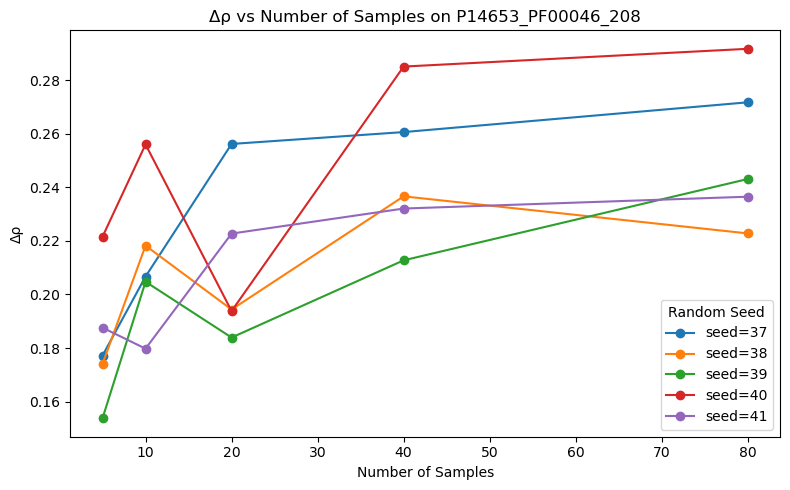

In [20]:
fig, ax = plt.subplots(figsize=(8, 5))

for seed, group in domain_df.groupby("random_seed"):
    group = group.sort_values("num_samples")

    ax.plot(
        group["num_samples"],
        group["delta_rho"],
        marker="o",
        # linestyle="--",
        # alpha=0.5,
        label=f"seed={seed}"
    )

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Δρ")
ax.set_title("Δρ vs Number of Samples on P14653_PF00046_208")
ax.legend(title="Random Seed")
ax.grid(False)

plt.tight_layout()
plt.show()

In [15]:
corr_df['pfam'] = corr_df['domain_id'].str.split("_").str[1]

In [23]:
pfam_df = corr_df[corr_df['pfam']=='PF00046']

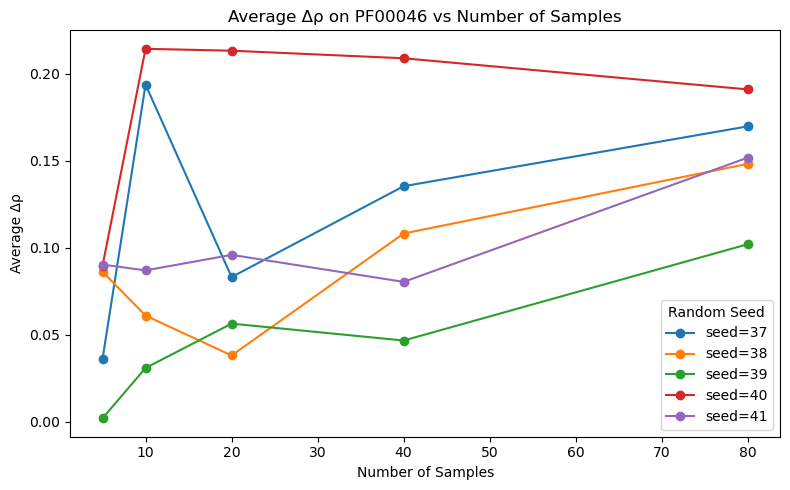

In [24]:
summary = (
    pfam_df.groupby(["random_seed", "num_samples"])["delta_rho"]
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

for seed, group in summary.groupby("random_seed"):
    group = group.sort_values("num_samples")

    ax.plot(
        group["num_samples"],
        group["delta_rho"],
        marker="o",
        label=f"seed={seed}"
    )

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Average Δρ")
ax.set_title("Average Δρ on PF00046 vs Number of Samples")
ax.legend(title="Random Seed")
ax.grid(False)

plt.tight_layout()
plt.show()

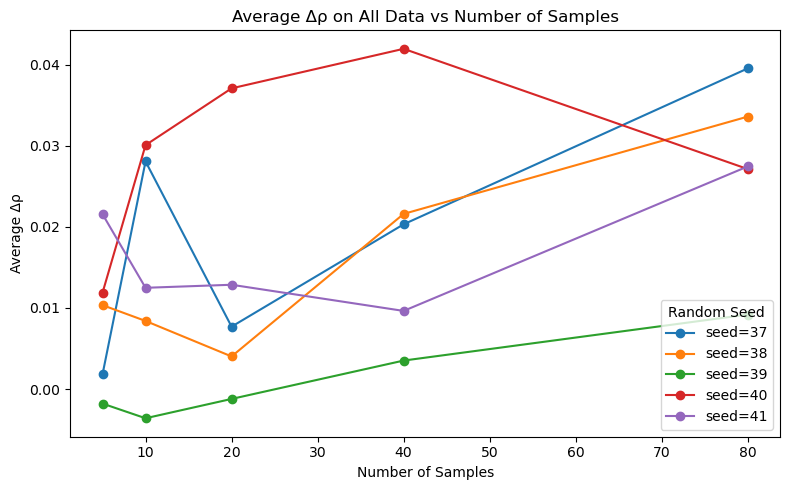

In [22]:
summary = (
    corr_df.groupby(["random_seed", "num_samples"])["delta_rho"]
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

for seed, group in summary.groupby("random_seed"):
    group = group.sort_values("num_samples")

    ax.plot(
        group["num_samples"],
        group["delta_rho"],
        marker="o",
        label=f"seed={seed}"
    )

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Average Δρ")
ax.set_title("Average Δρ on All Data vs Number of Samples")
ax.legend(title="Random Seed")
ax.grid(False)

plt.tight_layout()
plt.show()

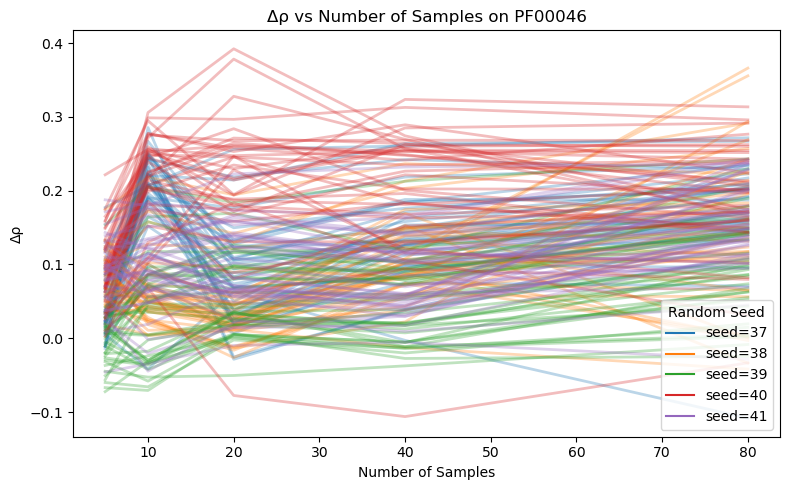

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))

# assign one color per seed
seeds = sorted(pfam_df["random_seed"].unique())
colors = plt.cm.tab10(range(len(seeds)))
seed_to_color = dict(zip(seeds, colors))

for (seed, domain_id), group in pfam_df.groupby(["random_seed", "domain_id"]):
    group = group.sort_values("num_samples")

    ax.plot(
        group["num_samples"],
        group["delta_rho"],
        color=seed_to_color[seed],
        alpha=0.3,      # makes overlapping lines easier to see
        linewidth=2
    )

# add one legend entry per seed
for seed in seeds:
    ax.plot([], [],
            color=seed_to_color[seed],
            label=f"seed={seed}")

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Δρ")
ax.set_title("Δρ vs Number of Samples on PF00046")
ax.legend(title="Random Seed")
ax.grid(False)

plt.tight_layout()
plt.show()

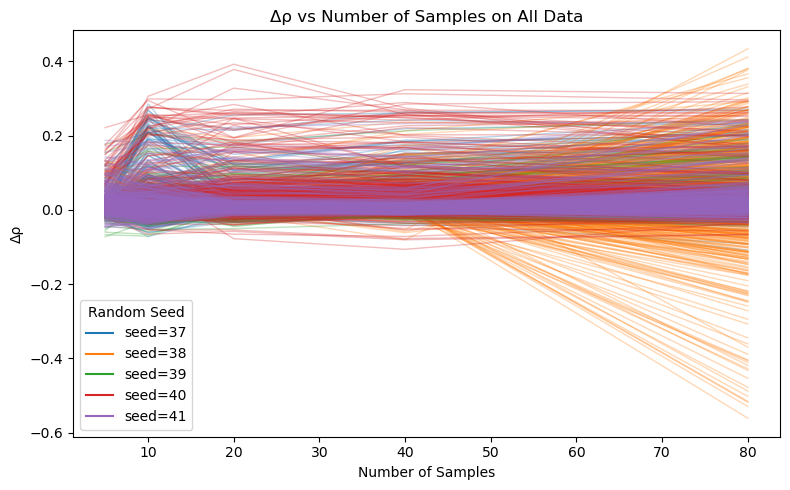

In [26]:
fig, ax = plt.subplots(figsize=(8, 5))

# assign one color per seed
seeds = sorted(corr_df["random_seed"].unique())
colors = plt.cm.tab10(range(len(seeds)))
seed_to_color = dict(zip(seeds, colors))

for (seed, domain_id), group in corr_df.groupby(["random_seed", "domain_id"]):
    group = group.sort_values("num_samples")

    ax.plot(
        group["num_samples"],
        group["delta_rho"],
        color=seed_to_color[seed],
        alpha=0.3,      # makes overlapping lines easier to see
        linewidth=1
    )

# add one legend entry per seed
for seed in seeds:
    ax.plot([], [],
            color=seed_to_color[seed],
            label=f"seed={seed}")

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Δρ")
ax.set_title("Δρ vs Number of Samples on All Data")
ax.legend(title="Random Seed")
ax.grid(False)

plt.tight_layout()
plt.show()

,run_id,num_samples,random_seed,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
2916,global_finetune_ns20_seed37,20,37,Q15911_PF00046_2643,Q15911,1044,0.227608,9.816908e-14,0.514763,1.050987e-71,0.287155,PF00046
10224,global_finetune_ns5_seed41,5,41,Q15911_PF00046_2643,Q15911,1044,0.227608,9.816908e-14,0.500612,2.594859e-67,0.273004,PF00046
4404,global_finetune_ns20_seed40,20,40,P78424_PF00046_609,P78424,991,0.255199,3.377114e-16,0.524101,5.186745e-71,0.268902,PF00046
2959,global_finetune_ns20_seed37,20,37,Q86UP3_PF00046_2562,Q86UP3,1021,0.224912,3.563763e-13,0.493366,9.611110e-64,0.268454,PF00046
10223,global_finetune_ns5_seed41,5,41,Q15911_PF00046_2244,Q15911,1027,0.315460,3.655389e-25,0.580364,1.649039e-93,0.264904,PF00046
...,...,...,...,...,...,...,...,...,...,...,...,...
5387,global_finetune_ns40_seed37,40,37,P35548_PF00046_144,P35548,1040,0.354596,3.573634e-32,-0.261095,1.140193e-17,-0.615691,PF00046
5297,global_finetune_ns40_seed37,40,37,O95343_PF00046_212,O95343,947,0.544174,4.156211e-74,-0.074627,2.163612e-02,-0.618801,PF00046
5655,global_finetune_ns40_seed37,40,37,Q9BZM3_PF00046_204,Q9BZM3,1028,0.412264,1.889501e-43,-0.220393,8.948922e-13,-0.632657,PF00046
5383,global_finetune_ns40_seed37,40,37,P28360_PF00046_174,P28360,1023,0.367771,4.077396e-34,-0.286464,8.953178e-21,-0.654234,PF00046


In [7]:
corr_df['pfam'] = corr_df['domain_id'].str.split("_").str[1]

In [12]:
corr_df.tail()

,run_id,num_samples,random_seed,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
9541,global_finetune_ns5_seed40,5,40,P19878_PF00018_241,P19878,1108,0.695403,6.692710e-161,-0.167410,2.072589e-08,-0.862813,PF00018
1901,global_finetune_ns10_seed40,10,40,Q7Z3T8_PF01363_744,Q7Z3T8,1122,0.539826,7.323062e-86,-0.325578,4.074248e-29,-0.865404,PF01363
2051,global_finetune_ns10_seed40,10,40,Q9UHC7_PF00642_89,Q9UHC7,415,0.504873,3.164116e-28,-0.378238,1.457874e-15,-0.883111,PF00642
5358,global_finetune_ns40_seed37,40,37,P15498_PF00018_782,P15498,1136,0.731991,3.353434e-191,-0.167576,1.330692e-08,-0.899567,PF00018
1663,global_finetune_ns10_seed40,10,40,P04150_PF00105_419,P04150,1410,0.696837,1.782626e-205,-0.265911,3.004073e-24,-0.962748,PF00105


In [14]:
corr_df.shape

(13050, 12)

In [27]:
corr_df.to_csv("/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_single_domain_NS_RS_df.csv.gz", index=False, compression="gzip")

In [45]:
stats_df = (
    corr_df.groupby(["num_samples", "random_seed"])["delta_rho"]
      .agg(
          mean="mean",
          variance="var",
          std="std",
          count="count"
      )
      .reset_index()
)

print(stats_df)

    num_samples  random_seed      mean      variance       std  count
0             5           37 -0.053670  5.767299e-03  0.075943    522
1             5           38 -0.000071  2.168961e-08  0.000147    522
2             5           39  0.004420  2.049777e-03  0.045274    522
3             5           40 -0.411666  2.747083e-02  0.165743    522
4             5           41  0.070175  5.262594e-03  0.072544    522
5            10           37 -0.043081  1.892890e-02  0.137582    522
6            10           38 -0.000047  2.196119e-08  0.000148    522
7            10           39  0.024554  2.015242e-03  0.044891    522
8            10           40 -0.460640  3.409722e-02  0.184654    522
9            10           41  0.014222  1.491224e-03  0.038616    522
10           20           37  0.053819  1.101431e-02  0.104949    522
11           20           38 -0.000097  5.424376e-08  0.000233    522
12           20           39 -0.115425  1.110822e-02  0.105396    522
13           20     

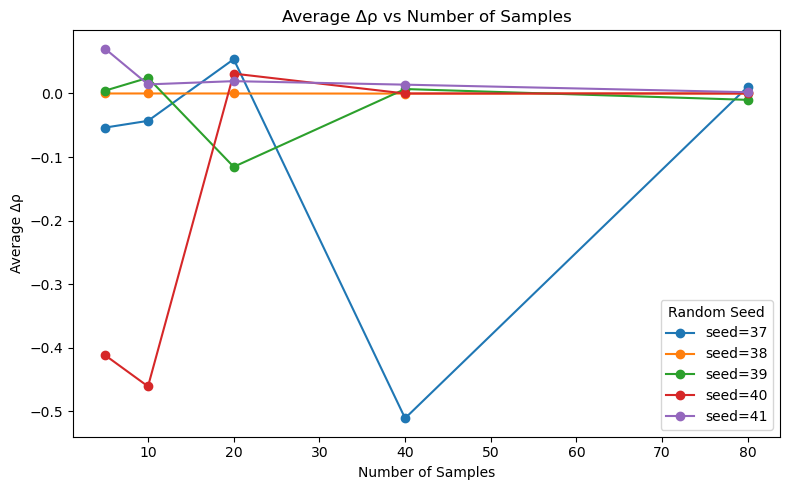

In [18]:
summary = (
    corr_df.groupby(["random_seed", "num_samples"])["delta_rho"]
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

for seed, group in summary.groupby("random_seed"):
    group = group.sort_values("num_samples")

    ax.plot(
        group["num_samples"],
        group["delta_rho"],
        marker="o",
        label=f"seed={seed}"
    )

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Average Δρ")
ax.set_title("Average Δρ vs Number of Samples")
ax.legend(title="Random Seed")
ax.grid(False)

plt.tight_layout()
plt.show()

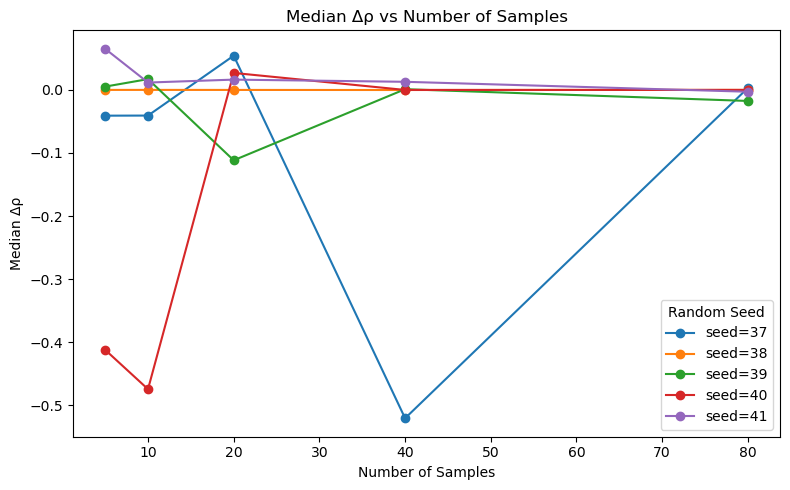

In [53]:
summary_med = (
    corr_df.groupby(["random_seed", "num_samples"])["delta_rho"]
      .median()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

for seed, group in summary_med.groupby("random_seed"):
    group = group.sort_values("num_samples")

    ax.plot(
        group["num_samples"],
        group["delta_rho"],
        marker="o",
        label=f"seed={seed}"
    )

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Median Δρ")
ax.set_title("Median Δρ vs Number of Samples")
ax.legend(title="Random Seed")
ax.grid(False)

plt.tight_layout()
plt.show()

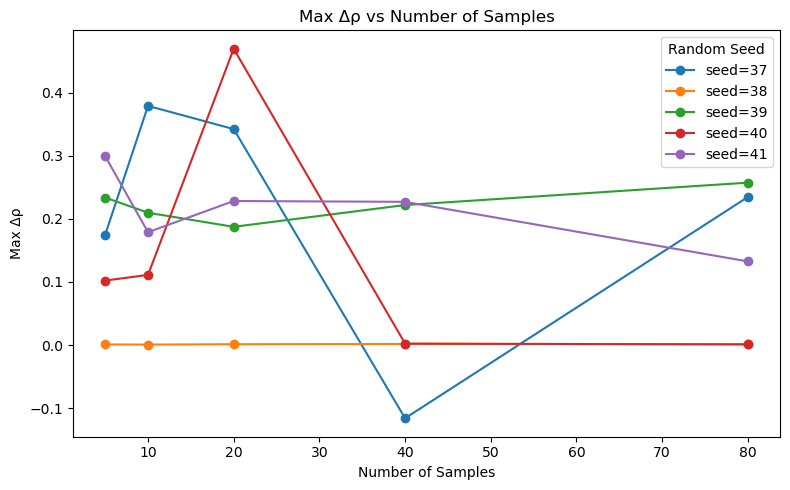

In [52]:
summary_max = (
    corr_df.groupby(["random_seed", "num_samples"])["delta_rho"]
      .max()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(8, 5))

for seed, group in summary_max.groupby("random_seed"):
    group = group.sort_values("num_samples")

    ax.plot(
        group["num_samples"],
        group["delta_rho"],
        marker="o",
        label=f"seed={seed}"
    )

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Max Δρ")
ax.set_title("Max Δρ vs Number of Samples")
ax.legend(title="Random Seed")
ax.grid(False)

plt.tight_layout()
plt.show()

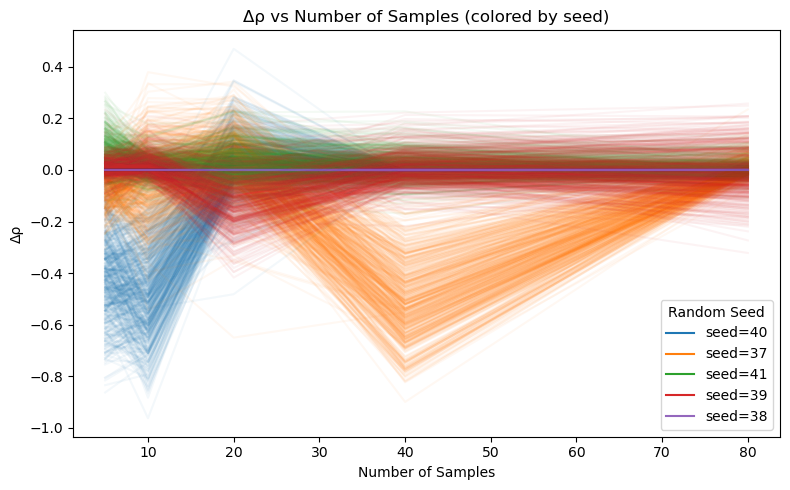

In [58]:
fig, ax = plt.subplots(figsize=(8, 5))

seeds = corr_df["random_seed"].unique()
colors = plt.cm.tab10(range(len(seeds)))

for seed, color in zip(seeds, colors):
    seed_df = corr_df[corr_df["random_seed"] == seed]

    for domain, group in seed_df.groupby("domain_id"):
        group = group.sort_values("num_samples")

        ax.plot(
            group["num_samples"],
            group["delta_rho"],
            color=color,
            alpha=0.05  # keep lines faint since many domains
        )

# Create a fake legend for seeds
for seed, color in zip(seeds, colors):
    ax.plot([], [], color=color, label=f"seed={seed}")

ax.set_xlabel("Number of Samples")
ax.set_ylabel("Δρ")
ax.set_title("Δρ vs Number of Samples (colored by seed)")
ax.legend(title="Random Seed")
ax.grid(False)

plt.tight_layout()
plt.show()

In [44]:
summary

,random_seed,num_samples,delta_rho
0,37,5,-0.053670
1,37,10,-0.043081
2,37,20,0.053819
3,37,40,-0.510712
4,37,80,0.010675
5,38,5,-0.000071
6,38,10,-0.000047
7,38,20,-0.000097
8,38,40,-0.000233
9,38,80,-0.000080


In [48]:
sum_stats_df = (
    summary.groupby(["num_samples"])["delta_rho"]
      .agg(
          mean="mean",
          variance="var",
          std="std",
          count="count"
      )
      .reset_index()
)

print(sum_stats_df)

   num_samples      mean  variance       std  count
0            5 -0.078163  0.036687  0.191537      5
1           10 -0.092998  0.042902  0.207127      5
2           20 -0.002240  0.004385  0.066220      5
3           40 -0.098064  0.053246  0.230750      5
4           80  0.000483  0.000055  0.007386      5


In [49]:
sum_stats_df = (
    summary.groupby(["random_seed"])["delta_rho"]
      .agg(
          mean="mean",
          variance="var",
          std="std",
          count="count"
      )
      .reset_index()
)

print(sum_stats_df)

   random_seed      mean      variance       std  count
0           37 -0.108594  5.240258e-02  0.228916      5
1           38 -0.000106  5.370701e-09  0.000073      5
2           39 -0.017925  3.122082e-03  0.055876      5
3           40 -0.168248  6.027364e-02  0.245507      5
4           41  0.023890  7.100722e-04  0.026647      5


In [36]:
corr42_df = pd.read_csv("/Users/johnhutchens/Desktop/Practicum/Data/ESM2_ft_all_pfam_sp.csv.gz")

In [59]:
corr42_df['delta_rho'].describe()

count    66294.000000
mean        -0.007345
std          0.096936
min         -0.992379
25%         -0.005302
50%          0.001864
75%          0.016981
max          0.529710
Name: delta_rho, dtype: float64

In [46]:
print(f"For ns = 20 and rs = 42 mean delta_rho is {corr42_df['delta_rho'].mean()}")
print(f"For ns = 20 and rs = 42 median delta_rho is {corr42_df['delta_rho'].median()}")
print(f"For ns = 20 and rs = 42 sd of delta_rho is {corr42_df['delta_rho'].std()}")

For ns = 20 and rs = 42 mean delta_rho is -0.007344531434839189
For ns = 20 and rs = 42 median delta_rho is 0.0018641026076971498
For ns = 20 and rs = 42 sd of delta_rho is 0.09693613483774785


In [39]:
corr42_all_df = corr42_df[corr42_df['domain_id']=='all_pfams']

In [ ]:
"""Pull every sweep_curves.json for RANDOM_SEED=38 across single-domain runs
and summarize the val_rho trajectories, early-stopping behavior, and which
epoch's weights were actually saved as best_lora_state.

Reads from
gs://{GCS_BUCKET}/{GCS_OUTPUT_PREFIX}/single_domain_*_seed38/.
Each {ft_domain_id, num_samples} combination is a separate run_id, so the
results include one row per (ft_domain_id, ns, lr, lora_r).
"""

import re

GCS_BUCKET         = "domainome-data"
GCS_OUTPUT_PREFIX  = "ESM2/ft_single_domain_NS_RS/"
SEED               = 38
MAX_EPOCHS         = 20

# Limit scan to runs we care about; e.g. {5, 10, 20, 40, 80} or set to None
# to keep every ns discovered under GCS_OUTPUT_PREFIX for this seed.
NUM_SAMPLES_VALUES = None

load_dotenv()
if os.getenv("GOOGLE_APPLICATION_CREDENTIALS"):
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = os.environ["GOOGLE_APPLICATION_CREDENTIALS"]

client = storage.Client()
bucket = client.bucket(GCS_BUCKET)


def download_json(blob_path):
    return json.loads(bucket.blob(blob_path).download_as_bytes().decode("utf-8"))


def replay_save_epoch(val_losses, val_rhos):
    """Replay the single-domain trainer's OR-condition save logic.

    Returns the 1-indexed epoch whose LoRA weights would end up in
    best_lora_state.
    """
    best_loss = float("inf")
    best_rho  = -float("inf")
    saved    = None
    for i, (vl, vr) in enumerate(zip(val_losses, val_rhos), start=1):
        if vl < best_loss or vr > best_rho:
            best_loss = min(vl, best_loss)
            best_rho  = max(vr, best_rho)
            saved    = i
    return saved


_SD_RUN_RE = re.compile(
    rf"^single_domain_(?P<ft_domain_id>.+)_ns(?P<ns>\d+)_seed{SEED}$"
)

discovered = []
for blob in client.list_blobs(GCS_BUCKET, prefix=GCS_OUTPUT_PREFIX):
    rel = blob.name[len(GCS_OUTPUT_PREFIX):]
    if rel.count("/") != 1 or not rel.endswith("/metadata.json"):
        continue
    run_id = rel.split("/", 1)[0]
    m = _SD_RUN_RE.match(run_id)
    if not m:
        continue
    ns = int(m.group("ns"))
    if NUM_SAMPLES_VALUES is not None and ns not in NUM_SAMPLES_VALUES:
        continue
    discovered.append((run_id, m.group("ft_domain_id"), ns))

discovered.sort(key=lambda x: (x[2], x[1]))
print(f"Discovered {len(discovered)} seed={SEED} single-domain runs")

rows = []
for run_id, ft_domain_id, ns in discovered:
    try:
        sweep = download_json(f"{GCS_OUTPUT_PREFIX}{run_id}/sweep_curves.json")
        meta  = download_json(f"{GCS_OUTPUT_PREFIX}{run_id}/metadata.json")
    except Exception as exc:
        print(f"[{run_id}] skip: {exc}")
        continue

    best_cfg = meta.get("best_config") or {}

    for r in sweep:
        vrs = r.get("val_rhos") or []
        vls = r.get("val_losses") or []
        if not vrs or not vls:
            continue

        saved_ep    = replay_save_epoch(vls, vrs)
        best_rho_ep = int(np.argmax(vrs)) + 1
        min_loss_ep = int(np.argmin(vls)) + 1

        rows.append({
            "ft_domain_id":       ft_domain_id,
            "ns":                 ns,
            "lr":                 r["lr"],
            "lora_r":             r["lora_r"],
            "epochs_ran":         r["epochs_ran"],
            "early_stopped":      r["epochs_ran"] < MAX_EPOCHS,
            "val_rho_e1":         round(vrs[0],   4),
            "val_rho_last":       round(vrs[-1],  4),
            "val_rho_max":        round(max(vrs), 4),
            "val_rho_spread":     round(max(vrs) - min(vrs), 4),
            "best_rho_epoch":     best_rho_ep,
            "min_loss_epoch":     min_loss_ep,
            "saved_epoch":        saved_ep,
            "saved_is_bestrho":   saved_ep == best_rho_ep,
            "stored_best_rho":    round(r.get("best_val_rho",  float("nan")), 4),
            "stored_best_loss":   round(r.get("best_val_loss", float("nan")), 4),
            "is_chosen_winner":   (r["lr"]     == best_cfg.get("lr")
                                   and r["lora_r"] == best_cfg.get("lora_r")),
        })

df = (
    pd.DataFrame(rows)
      .sort_values(["ns", "ft_domain_id", "lr", "lora_r"])
      .reset_index(drop=True)
)

print(f"\n=== seed={SEED} per-config sweep diagnostics ({len(df)} rows) ===\n")
with pd.option_context("display.max_rows", 60,
                       "display.width", 240,
                       "display.max_columns", None):
    print(df.head(60).to_string(index=False))

print(f"\n=== Per-NUM_SAMPLES summary (seed {SEED}) ===\n")
summary = df.groupby("ns").agg(
    n_runs              = ("ft_domain_id",     "nunique"),
    n_configs           = ("epochs_ran",       "size"),
    median_epochs       = ("epochs_ran",       "median"),
    pct_early_stopped   = ("early_stopped",    "mean"),
    median_rho_spread   = ("val_rho_spread",   "median"),
    pct_saved_neq_best  = ("saved_is_bestrho", lambda s: 1.0 - s.mean()),
)
print(summary.to_string())

print("\n=== Sweep-chosen winners (one per (ft_domain_id, NUM_SAMPLES)) ===\n")
winners = df[df["is_chosen_winner"]].copy()
print(winners.head(40).to_string(index=False))

# out_csv = os.path.join(os.path.dirname(os.path.abspath(__file__)),
                    #    "seed38_sweep_summary.csv")
# df.to_csv(out_csv, index=False)
# print(f"\nWrote {out_csv}")


=== seed=38 per-config sweep diagnostics (80 rows) ===

 ns     lr  lora_r  epochs_ran  early_stopped  val_rho_e1  val_rho_last  val_rho_max  val_rho_spread  best_rho_epoch  min_loss_epoch  saved_epoch  saved_is_bestrho  stored_best_rho  stored_best_loss  is_chosen_winner
  5 0.0001       8           3           True      0.4475        0.4474       0.4475          0.0001               1               1            1              True           0.4475            0.0635              True
  5 0.0001      16           3           True      0.4475        0.4473       0.4475          0.0002               1               1            1              True           0.4475            0.0638             False
  5 0.0001      64           3           True      0.4470        0.4462       0.4470          0.0009               1               1            1              True           0.4470            0.0656             False
  5 0.0001     128           3           True      0.4465        0.4448    

array(['PF00010', 'PF11722', 'PF00569', 'PF02209', 'PF02187', 'PF01246',
       'PF06467', 'PF10650', 'PF02008', 'PF18044', 'PF01429', 'PF02295',
       'PF00787', 'PF18112', 'PF09329', 'PF02207', 'PF00013', 'PF00412',
       'PF00533', 'PF05225', 'PF00567', 'PF00536', 'PF05715', 'PF13639',
       'PF02185', 'PF00096', 'PF00642', 'PF00240', 'PF00831', 'PF02037',
       'PF00320', 'PF12171', 'PF00619', 'PF00595', 'PF00458', 'PF06220',
       'PF11793', 'PF16557', 'PF00249', 'PF07647', 'PF00035', 'PF00280',
       'PF05605', 'PF08313', 'PF02270', 'PF17035', 'PF00627', 'PF00538',
       'PF01846', 'PF00778', 'PF01480', 'PF08073', 'PF02172', 'PF02376',
       'PF07525', 'PF01335', 'PF02845', 'PF14369', 'PF00505', 'PF01381',
       'PF13891', 'PF10264', 'PF00612', 'PF00130', 'PF03638', 'PF00046',
       'PF04855', 'PF02359', 'PF11515', 'PF18410', 'PF18366', 'PF00643',
       'PF02198', 'PF16558', 'PF02017', 'PF00385', 'PF02179', 'PF18694',
       'PF02196', 'PF00789', 'PF04433', 'PF12678', 

In [20]:
best_domains = (
    corr_df.loc[
        corr_df.groupby(["num_samples", "random_seed"])["delta_rho"].idxmax()
    ]
    .sort_values(["num_samples", "random_seed"])
)

best_domains = best_domains[
    [
        "num_samples",
        "random_seed",
        "domain_id",
        "uniprot_id",
        "pfam",
        "delta_rho",
        "rho_base",
        "rho_ft",
    ]
]

print(best_domains)

       num_samples  random_seed            domain_id uniprot_id     pfam  \
8185             5           37    Q8IV48_PF02037_65     Q8IV48  PF02037   
8713             5           38   Q8IZQ8_PF02037_363     Q8IZQ8  PF02037   
8890             5           39   O14776_PF01846_727     O14776  PF01846   
9866             5           40   Q9NYS7_PF07525_369     Q9NYS7  PF07525   
10071            5           41   P20936_PF00018_281     P20936  PF00018   
339             10           37   Q7Z6G8_PF00536_812     Q7Z6G8  PF00536   
883             10           38   Q8IZQ8_PF02037_363     Q8IZQ8  PF02037   
1564            10           39   Q9Y6N9_PF00595_207     Q9Y6N9  PF00595   
2036            10           40   Q9NYS7_PF07525_369     Q9NYS7  PF07525   
2608            10           41   Q9Y6N9_PF00595_207     Q9Y6N9  PF00595   
2765            20           37   P22681_PF00627_854     P22681  PF00627   
3336            20           38    P53674_PF00030_57     P53674  PF00030   
3737        

In [21]:
top10_domains = (
    corr_df.sort_values(
        ["num_samples", "random_seed", "delta_rho"],
        ascending=[True, True, False]
    )
    .groupby(["num_samples", "random_seed"])
    .head(10)
    .reset_index(drop=True)
)

top10_domains = top10_domains[
    [
        "num_samples",
        "random_seed",
        "domain_id",
        "uniprot_id",
        "pfam",
        "delta_rho",
        "rho_base",
        "rho_ft",
    ]
]

print(top10_domains)

     num_samples  random_seed           domain_id uniprot_id     pfam  \
0              5           37   Q8IV48_PF02037_65     Q8IV48  PF02037   
1              5           37  P09327_PF02209_793     P09327  PF02209   
2              5           37   Q8N5C8_PF02845_12     Q8N5C8  PF02845   
3              5           37  P35712_PF00505_622     P35712  PF00505   
4              5           37  P35711_PF00505_557     P35711  PF00505   
..           ...          ...                 ...        ...      ...   
245           80           41  Q9UJ78_PF06467_334     Q9UJ78  PF06467   
246           80           41   Q9H9L4_PF13891_28     Q9H9L4  PF13891   
247           80           41   P54821_PF00046_96     P54821  PF00046   
248           80           41  Q9H161_PF00046_216     Q9H161  PF00046   
249           80           41  O95076_PF00046_155     O95076  PF00046   

     delta_rho  rho_base    rho_ft  
0     0.174679  0.462929  0.637607  
1     0.155983  0.186976  0.342959  
2     0.1464

In [50]:
top10_domains[top10_domains['num_samples']==10]

,num_samples,random_seed,domain_id,uniprot_id,pfam,delta_rho,rho_base,rho_ft
50,10,37,Q7Z6G8_PF00536_812,Q7Z6G8,PF00536,0.379074,0.257597,0.636671
51,10,37,Q9UJ78_PF06467_334,Q9UJ78,PF06467,0.336463,0.186368,0.522830
52,10,37,P55265_PF02295_296,P55265,PF02295,0.332344,0.248490,0.580835
53,10,37,P22681_PF00627_854,P22681,PF00627,0.303030,0.235314,0.538344
54,10,37,Q9HC78_PF00096_635,Q9HC78,PF00096,0.278387,0.330802,0.609189
55,10,37,P09327_PF02209_793,P09327,PF02209,0.263076,0.186976,0.450052
56,10,37,Q15911_PF00046_2643,Q15911,PF00046,0.245978,0.227608,0.473586
57,10,37,Q86UP3_PF00046_2562,Q86UP3,PF00046,0.245270,0.224912,0.470182
58,10,37,Q15365_PF00013_278,Q15365,PF00013,0.244369,0.370121,0.614490
59,10,37,P05813_PF00030_31,P05813,PF00030,0.241035,0.376448,0.617482


In [24]:
top10_domains['domain_id'].nunique()

117

In [25]:
top10_domains.shape

(250, 8)

In [26]:
print(
    corr_df.groupby('pfam')
    .size()
    .sort_values(ascending=False)
    .to_string()
)

pfam
PF00046     925
PF00018     900
PF00096     900
PF00595     775
PF00397     650
PF00505     425
PF00249     375
PF02037     350
PF01846     300
PF00157     300
PF00030     300
PF00628     275
PF00641     250
PF00105     250
PF00643     225
PF00313     225
PF00013     225
PF00642     200
PF00412     200
PF02376     200
PF06467     200
PF14604     200
PF00627     175
PF00536     150
PF00226     150
PF13499     150
PF02198     150
PF07647     125
PF02209     100
PF02196      75
PF02817      75
PF00630      75
rockdoms     75
PF00564      75
PF00130      75
PF00531      75
PF00619      50
PF06839      50
PF00385      50
PF02295      50
PF00320      50
PF00280      50
PF02845      50
PF04433      50
PF00612      50
PF07533      50
PF07525      50
PF08711      50
PF10264      50
PF11515      50
PF12171      50
PF13639      50
PF00035      50
PF00458      50
PF00010      50
PF00569      50
PF00646      50
PF01363      50
PF01485      50
PF00778      50
PF11793      25
PF13341      25
PF1

In [18]:
corr_df[corr_df['pfam']=='PF00046'].groupby('uniprot_id').size()

uniprot_id
O14813    1
O15266    1
O43186    1
O75360    1
O95076    1
O95343    1
O95475    1
P14653    1
P20264    1
P20265    1
P23759    1
P26367    1
P28360    1
P32243    1
P35548    1
P39880    1
P49335    1
P54821    1
P56915    1
P78424    1
Q15475    1
Q15699    1
Q15911    3
Q5SQQ9    1
Q86UP3    3
Q8NFW5    1
Q96QS3    1
Q9BZM3    1
Q9C0A1    1
Q9H161    1
Q9H2P0    1
Q9NPC8    1
Q9UBX0    1
dtype: int64

In [19]:
df = corr_df.copy()

long_df = df.melt(
    id_vars=['pfam'],
    value_vars=['rho_base', 'rho_ft'],
    var_name='condition',
    value_name='rho'
)

In [20]:
pfams = sorted(long_df['pfam'].unique())

base_data = []
ft_data = []

for pfam in pfams:
    base_data.append(long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_base')]['rho'])
    ft_data.append(long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_ft')]['rho'])

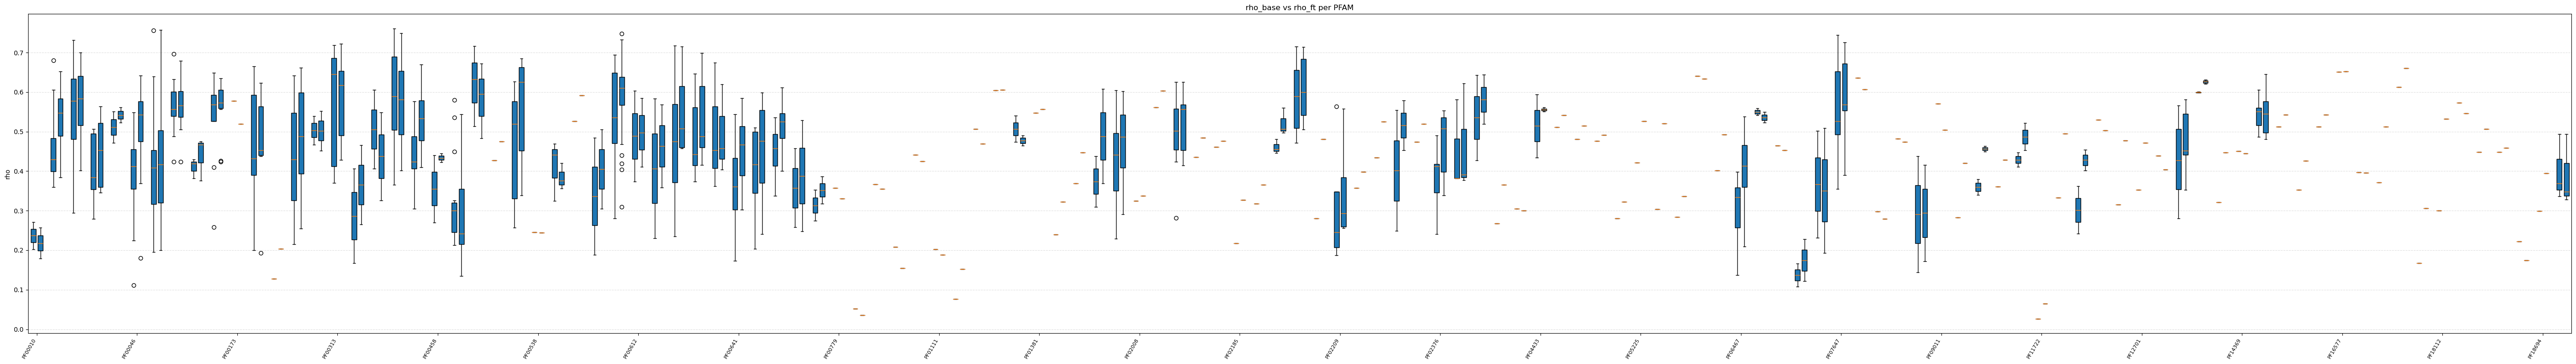

In [23]:
fig, ax = plt.subplots(figsize=(56, 8))

positions_base = np.arange(len(pfams)) * 2
positions_ft = positions_base + 0.7

# Boxplots
ax.boxplot(
    base_data,
    positions=positions_base,
    widths=0.5,
    patch_artist=True
)

ax.boxplot(
    ft_data,
    positions=positions_ft,
    widths=0.5,
    patch_artist=True
)

# Show only every nth label
step = 5

ax.set_xticks((positions_base + 0.35)[::step])
ax.set_xticklabels(
    np.array(pfams)[::step],
    rotation=60,
    ha='right',
    fontsize=8
)

ax.set_ylabel("rho")
ax.set_title("rho_base vs rho_ft per PFAM")

# Light grid
ax.grid(axis='y', linestyle='--', alpha=0.4)

# Reduce empty margins
ax.margins(x=0.005)

plt.tight_layout()
plt.show()

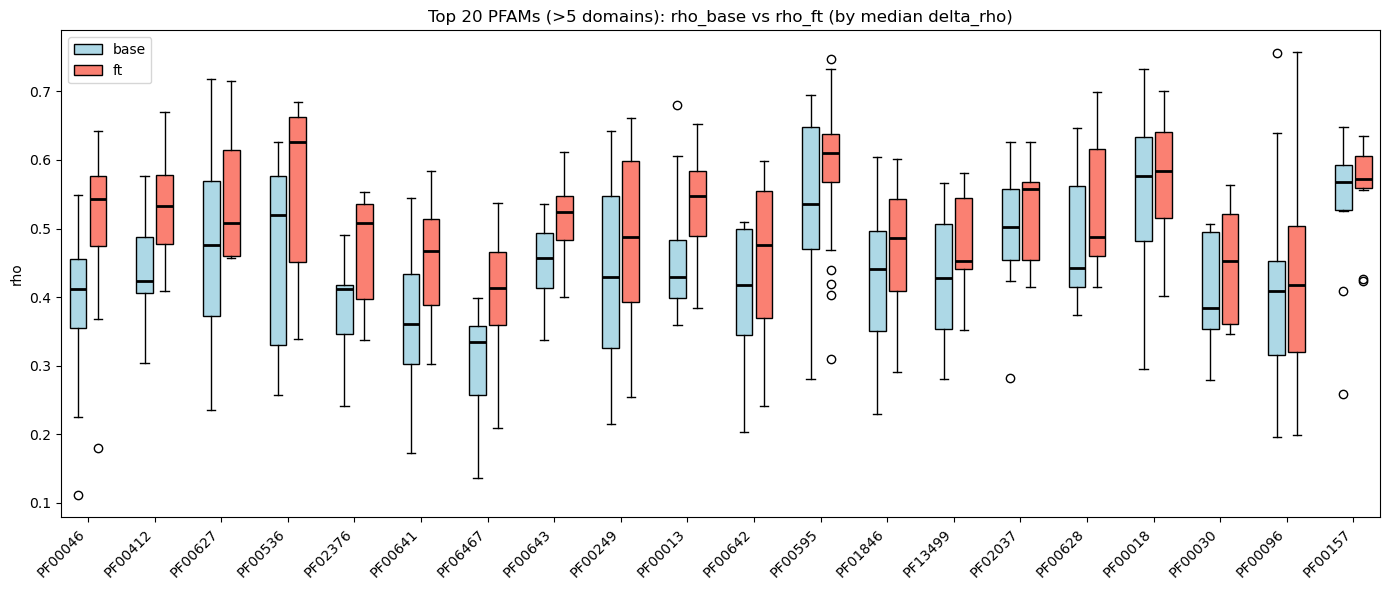

In [24]:
# --- Step 1: filter PFAMs with enough samples ---
pfam_counts = corr_df['pfam'].value_counts()
valid_pfams = pfam_counts[pfam_counts > 5].index
df_filt = corr_df[corr_df['pfam'].isin(valid_pfams)].copy()

# --- Step 2: select top 20 PFAMs by median delta_rho ---
top_pfams = (
    df_filt.groupby('pfam')['delta_rho']
    .median()
    .sort_values(ascending=False)
    .head(20)
    .index
)

df_top = df_filt[df_filt['pfam'].isin(top_pfams)].copy()

# --- Step 3: reshape for plotting ---
long_df = df_top.melt(
    id_vars=['pfam'],
    value_vars=['rho_base', 'rho_ft'],
    var_name='condition',
    value_name='rho'
)

# --- Step 4: build boxplot data ---
pfams = list(top_pfams)

base_data = []
ft_data = []

for pfam in pfams:
    base_data.append(
        long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_base')]['rho']
    )
    ft_data.append(
        long_df[(long_df['pfam'] == pfam) & (long_df['condition'] == 'rho_ft')]['rho']
    )

# --- Step 5: plot ---
fig, ax = plt.subplots(figsize=(14, 6))

x = np.arange(len(pfams)) * 2
x_ft = x + 0.6

ax.boxplot(base_data, positions=x, patch_artist=True, 
           boxprops=dict(facecolor='lightblue'), label='base',
           medianprops=dict(color='black', linewidth=2))
ax.boxplot(ft_data, positions=x_ft, patch_artist=True, 
           boxprops=dict(facecolor='salmon'), label='ft',
           medianprops=dict(color='black', linewidth=2))

ax.set_xticks(x + 0.3)
ax.set_xticklabels(pfams, rotation=45, ha='right')

ax.set_ylabel("rho")
ax.set_title("Top 20 PFAMs (>5 domains): rho_base vs rho_ft (by median delta_rho)")

plt.legend()
plt.tight_layout()
plt.show()

In [27]:
long_df.head()

,pfam,condition,rho
0,PF00595,rho_base,0.378841
1,PF00018,rho_base,0.422455
2,PF00627,rho_base,0.235321
3,PF00046,rho_base,0.320946
4,PF06467,rho_base,0.186344


In [28]:
corr_df[['domain_id', 'n', 'uniprot_id', 'pfam', 'rho_base', 'rho_ft', 'delta_rho']].sort_values('delta_rho', ascending=False).head(20)

,domain_id,n,uniprot_id,pfam,rho_base,rho_ft,delta_rho
520,Q9Y6N9_PF00595_207,1255,Q9Y6N9,PF00595,0.378841,0.626113,0.247273
153,P20936_PF00018_281,1158,P20936,PF00018,0.422455,0.666934,0.244478
350,Q86VP1_PF18112_729,494,Q86VP1,PF18112,0.299746,0.531721,0.231975
155,P22681_PF00627_854,850,P22681,PF00627,0.235321,0.457588,0.222268
472,Q9P0J7_PF05605_76,1093,Q9P0J7,PF05605,0.303563,0.520061,0.216498
452,Q9HA38_PF12171_246,493,Q9HA38,PF12171,0.241383,0.454476,0.213094
304,Q15911_PF00046_2147,1055,Q15911,PF00046,0.320946,0.530777,0.209831
212,P55265_PF02295_296,1147,P55265,PF02295,0.248485,0.452711,0.204227
352,Q86XK2_PF02207_849,867,Q86XK2,PF02207,0.280419,0.481052,0.200633
488,Q9UJ78_PF06467_334,678,Q9UJ78,PF06467,0.186344,0.376822,0.190478


In [29]:
corr_df.head()

,domain_id,uniprot_id,n,rho_base,p_base,rho_ft,p_ft,delta_rho,pfam
520,Q9Y6N9_PF00595_207,Q9Y6N9,1255,0.378841,4.165029e-44,0.626113,1.456364e-137,0.247273,PF00595
153,P20936_PF00018_281,P20936,1158,0.422455,2.486852e-51,0.666934,6.875281e-150,0.244478,PF00018
350,Q86VP1_PF18112_729,Q86VP1,494,0.299746,1.029321e-11,0.531721,2.119634e-37,0.231975,PF18112
155,P22681_PF00627_854,P22681,850,0.235321,3.693812e-12,0.457588,3.250431e-45,0.222268,PF00627
472,Q9P0J7_PF05605_76,Q9P0J7,1093,0.303563,9.848891e-25,0.520061,9.076428e-77,0.216498,PF05605


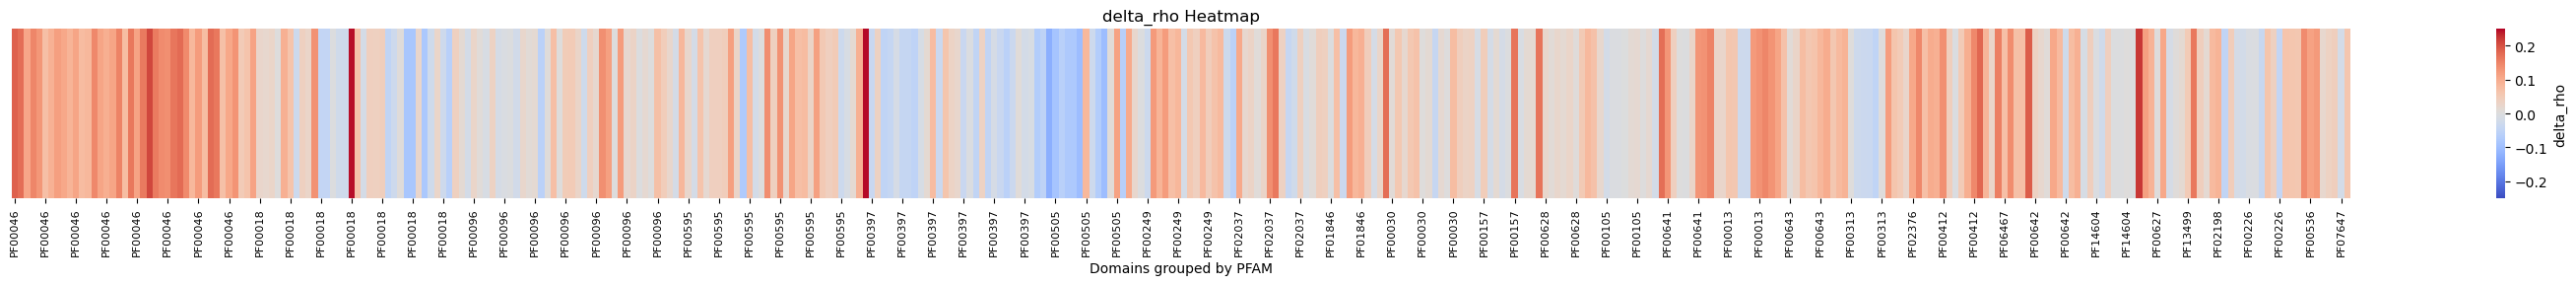

In [31]:
# Count domains per PFAM
pfam_counts = df['pfam'].value_counts()

# Keep only PFAMs with >= 5 domains
valid_pfams = pfam_counts[pfam_counts >= 5].index

filtered = df[df['pfam'].isin(valid_pfams)].copy()

# Order PFAMs by number of domains (descending)
pfam_order = (
    filtered['pfam']
    .value_counts()
    .index
)

# Sort dataframe by PFAM order
filtered['pfam'] = pd.Categorical(
    filtered['pfam'],
    categories=pfam_order,
    ordered=True
)

filtered = filtered.sort_values(['pfam', 'domain_id'])

# Create 1-row heatmap matrix
heatmap_data = np.array([filtered['delta_rho'].values])

# Plot
fig, ax = plt.subplots(figsize=(30, 3))

sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    center=0,
    vmin=-0.25,
    vmax=0.25,
    cbar_kws={'label': 'delta_rho'},
    xticklabels=filtered['pfam'].values,
    yticklabels=[],
    ax=ax
)

# Reduce x tick clutter
step = 5
ticks = np.arange(len(filtered))[::step]

ax.set_xticks(ticks + 0.5)
ax.set_xticklabels(
    filtered['pfam'].values[::step],
    rotation=90,
    fontsize=8
)

ax.set_xlabel("Domains grouped by PFAM")
ax.set_title("delta_rho Heatmap")

plt.tight_layout()
plt.show()

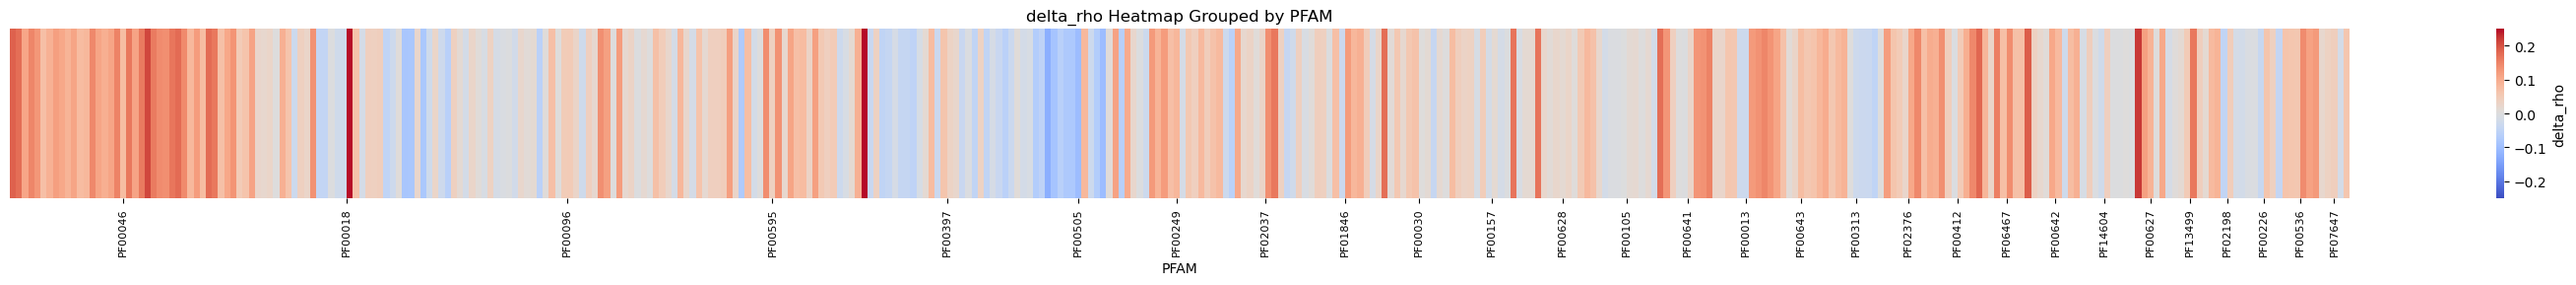

In [32]:
# Count domains per PFAM
pfam_counts = df['pfam'].value_counts()

# Keep only PFAMs with >= 5 domains
valid_pfams = pfam_counts[pfam_counts >= 5].index

filtered = df[df['pfam'].isin(valid_pfams)].copy()

# Order PFAMs by number of domains (descending)
pfam_order = (
    filtered['pfam']
    .value_counts()
    .index
)

# Set categorical ordering
filtered['pfam'] = pd.Categorical(
    filtered['pfam'],
    categories=pfam_order,
    ordered=True
)

# Sort by PFAM then domain
filtered = filtered.sort_values(['pfam', 'domain_id'])

# Heatmap data
heatmap_data = np.array([filtered['delta_rho'].values])

# Plot
fig, ax = plt.subplots(figsize=(30, 3))

sns.heatmap(
    heatmap_data,
    cmap='coolwarm',
    center=0,
    vmin=-0.25,
    vmax=0.25,
    cbar_kws={'label': 'delta_rho'},
    xticklabels=False,
    yticklabels=[],
    ax=ax
)

# Compute centered tick positions for each PFAM block
tick_positions = []
tick_labels = []

start = 0

for pfam in pfam_order:
    count = (filtered['pfam'] == pfam).sum()

    center = start + count / 2
    tick_positions.append(center)
    tick_labels.append(pfam)

    start += count

# Set centered PFAM labels
ax.set_xticks(tick_positions)
ax.set_xticklabels(
    tick_labels,
    rotation=90,
    fontsize=8
)

ax.set_xlabel("PFAM")
ax.set_title("delta_rho Heatmap Grouped by PFAM")

plt.tight_layout()
plt.show()

In [35]:
filename = "ESM2_ft_single_domain_NS_RS_sp_df.csv.gz"

buffer = BytesIO()

with gzip.GzipFile(fileobj=buffer, mode="wb") as gz:
    gz.write(
        corr_df.to_csv(index=False).encode("utf-8")
    )

buffer.seek(0)

# Upload combined per-(run, domain) Spearman table to the NS/RS prefix root.
bucket_name = GCS_BUCKET
destination_blob = f"{GCS_OUTPUT_PREFIX}{filename}"

client = storage.Client()
bucket = client.bucket(bucket_name)
blob = bucket.blob(destination_blob)

blob.upload_from_file(
    buffer,
    content_type="application/gzip"
)

print(f"Uploaded to gs://{bucket_name}/{destination_blob}")

Uploaded to gs://domainome-data/ESM2/ft_all_doms_run2/global_finetune/ESM2_ft_all_sp_df.csv.gz
